In [1]:
import source.helpers
import biolib
from pathlib import Path
import pandas as pd

from source import analysis, data, predict, regions
from source import path_method as pm

C:\Users\domin\anaconda3\envs\GLUT\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
grouped = True
if grouped:
    proteins = {
    'GLUT1':'P11166',
    'GLUT2':'P11168',
    'GLUT3':'P11169',
    'GLUT4':'P14672',
    'GLUT14':'Q8TDB8',#group 1
    'GLUT5':'P22732',
    'GLUT7':'Q6PXP3',
    'GLUT9':'Q9NRM0',
    'GLUT11':'Q9BYW1',#group2
    'GLUT6':'Q9UGQ3',
    'GLUT8':'Q9NY64',
    'GLUT10':'O95528',
    'GLUT12':'Q8TD20',
    'GLUT13':'Q96QE2' #group3
}
else:
    proteins = {
    'GLUT1':'P11166',
    'GLUT2':'P11168',
    'GLUT3':'P11169',
    'GLUT4':'P14672',
    'GLUT5':'P22732',
    'GLUT6':'Q9UGQ3',
    'GLUT7':'Q6PXP3',
    'GLUT8':'Q9NY64',
    'GLUT9':'Q9NRM0',
    'GLUT10':'O95528',
    'GLUT11':'Q9BYW1',
    'GLUT12':'Q8TD20',
    'GLUT13':'Q96QE2',
    'GLUT14':'Q8TDB8' 
    }

In [3]:
RES_DIR = Path.cwd() / 'results'
DATA_DIR = Path.cwd() / 'data'

R_RES_DIR = Path.cwd() / 'results/rowan_cut'
R_DATA_DIR = Path.cwd() / 'data/rowan_cut'

#if results and data direcotries not exists create them
Path.mkdir(R_RES_DIR, exist_ok=True)
Path.mkdir(R_DATA_DIR, exist_ok=True)

In [4]:
#get protein lengths

In [5]:
shift_f = open(R_DATA_DIR / 'shifts.csv')

In [6]:
prot_shifts = dict()
for line in shift_f:
    l = line.split(',')
    if l[0].startswith('GLUT'):
        up_id = proteins[l[0]]
        head = int(l[1])
        tail = int(l[2])
        length = int(data.get_protein_length(proteins[l[0]]))
        prot_shifts[proteins[l[0]]]={'head':head, 'tail':tail, 'length':length}

In [7]:
for p in proteins.values():
    prot_shifts[p]['new_end'] = prot_shifts[p]['length'] - prot_shifts[p]['tail']

In [8]:
prot_shifts

{'P11166': {'head': 11, 'tail': 42, 'length': 492, 'new_end': 450},
 'P11168': {'head': 9, 'tail': 42, 'length': 524, 'new_end': 482},
 'P11169': {'head': 9, 'tail': 48, 'length': 496, 'new_end': 448},
 'P14672': {'head': 23, 'tail': 43, 'length': 509, 'new_end': 466},
 'P22732': {'head': 16, 'tail': 42, 'length': 501, 'new_end': 459},
 'Q9UGQ3': {'head': 42, 'tail': 27, 'length': 507, 'new_end': 480},
 'Q6PXP3': {'head': 27, 'tail': 46, 'length': 512, 'new_end': 466},
 'Q9NY64': {'head': 30, 'tail': 20, 'length': 477, 'new_end': 457},
 'Q9NRM0': {'head': 55, 'tail': 43, 'length': 540, 'new_end': 497},
 'O95528': {'head': 7, 'tail': 45, 'length': 541, 'new_end': 496},
 'Q9BYW1': {'head': 12, 'tail': 41, 'length': 496, 'new_end': 455},
 'Q8TD20': {'head': 40, 'tail': 69, 'length': 617, 'new_end': 548},
 'Q96QE2': {'head': 89, 'tail': 56, 'length': 648, 'new_end': 592},
 'Q8TDB8': {'head': 34, 'tail': 48, 'length': 520, 'new_end': 472}}

In [9]:
p_regions = {'all':'all','intracellular':'I', 'extracellular':'O', 'transmembrane':'M'}
preds = ['alphamissense', 'sift', 'rhapsody']

In [10]:
#create rowan result directories
Path.mkdir(R_RES_DIR / r'pathogenicities', exist_ok=True)
for p in preds:
    Path.mkdir(R_RES_DIR / f'pathogenicities/{p}', exist_ok=True)

## pathogenicites cut

In [11]:
for pred in preds:
    pred_data_dir = RES_DIR / f'pathogenicities/{pred}'
    pred_res_dir = R_RES_DIR / f'pathogenicities/{pred}'
    for reg in p_regions.values():
        for prot in prot_shifts.keys():
            df = pd.read_csv(pred_data_dir / f'{reg}_{prot}.csv')
            df = df.query(f'{prot_shifts[prot]['head']} < residue_label < {prot_shifts[prot]['new_end']}')
            df.loc[:,['residue_label']] = df.loc[:,['residue_label']] - prot_shifts[prot]['head']
            df.to_csv(pred_res_dir / f'{reg}_{prot}.csv', index = False)
            
            
    

## averages

In [12]:
for prefix in p_regions.values():
    for pred in preds:
        work_dir = R_RES_DIR / f'pathogenicities/{pred}'
        analysis.average_pathogenicity(patho_dir = work_dir, region_prefix = prefix, up_id_list = proteins.values(), out_file = work_dir / f'{prefix}_average_patho.csv')



In [13]:
for pred in preds:
    directory =  R_RES_DIR / f'pathogenicities/{pred}'
    files = []
    for prefix in p_regions.values():
        files.append(directory / f'{prefix}_average_patho.csv')
    columns = ['identifier']+list(p_regions.keys())
    df = source.helpers.unite_csvs(files, directory / 'united_averages.csv', id_col = 1, colnames = columns, return_df = True)
df

,identifier,all,intracellular,extracellular,transmembrane
0,P11166,0.732208,0.721851,0.528242,0.785742
1,P11168,0.689163,0.725486,0.429772,0.773316
2,P11169,0.780183,0.780208,0.555690,0.840094
3,P14672,0.722199,0.642632,0.523028,0.800822
4,Q8TDB8,0.722982,0.732543,0.501289,0.787224
5,P22732,0.798765,0.798667,0.656197,0.839382
6,Q6PXP3,0.789034,0.778621,0.672513,0.831234
7,Q9NRM0,0.793859,0.741733,0.689789,0.840900
8,Q9BYW1,0.633955,0.614760,0.486561,0.676156
9,Q9UGQ3,0.808400,0.818061,0.597321,0.878231


In [14]:
#rename to GLUT names
for pred in preds:
    directory =  R_RES_DIR / f'pathogenicities/{pred}'
    for glut_id in proteins.keys():
        united_df = pd.read_csv(directory / 'united_averages.csv')
        i = united_df[united_df['identifier']==proteins[glut_id]].index
        united_df.at[i.values[0], 'identifier'] = glut_id
        united_df.to_csv(directory / 'united_averages.csv', index=False)

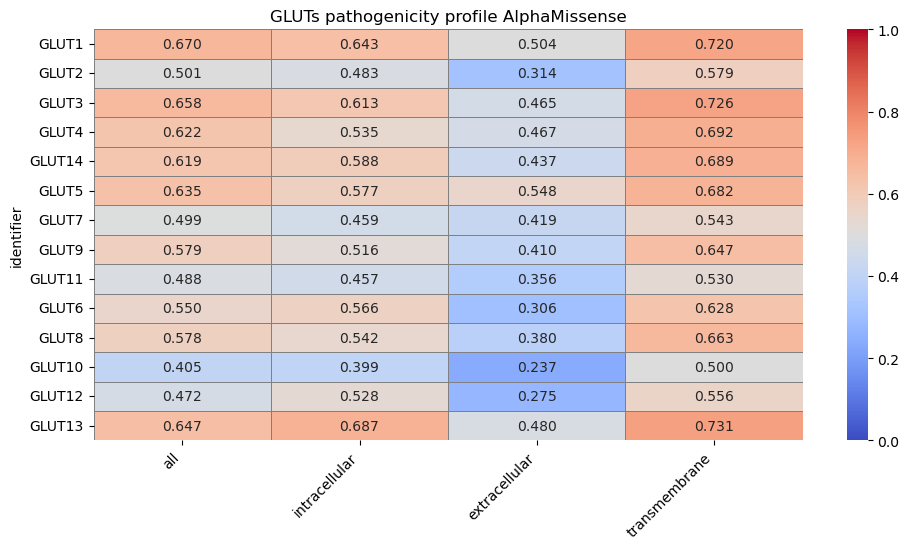

In [15]:
#create heatmaps
#alphamissense
analysis.crate_heatmap(R_RES_DIR / r'pathogenicities/alphamissense/united_averages.csv', 'AlphaMissense', R_RES_DIR / 'AlphaMissense_pathogenicity_heatmap.png')

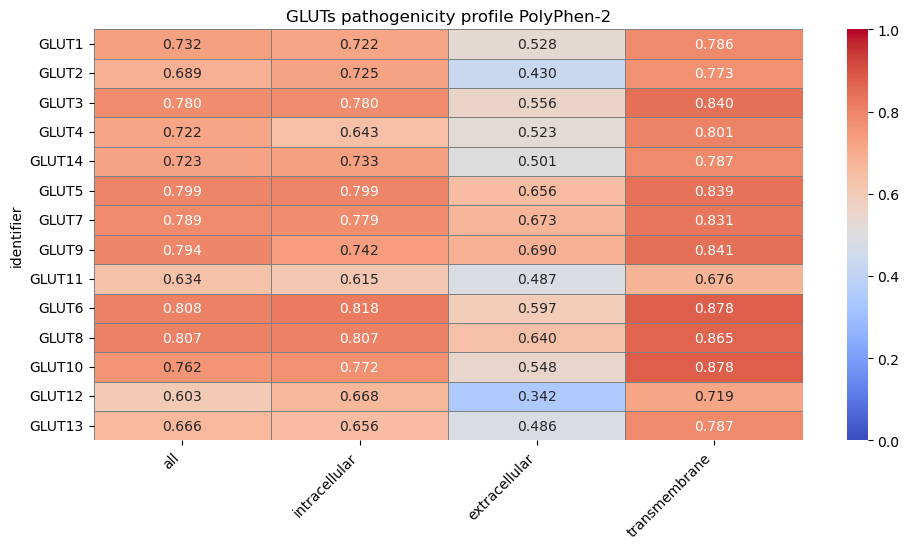

In [16]:
#create heatmaps
#polyphen-2
analysis.crate_heatmap(R_RES_DIR / r'pathogenicities/rhapsody/united_averages.csv', 'PolyPhen-2', R_RES_DIR / 'PolyPhen-2_pathogenicity_heatmap.png')

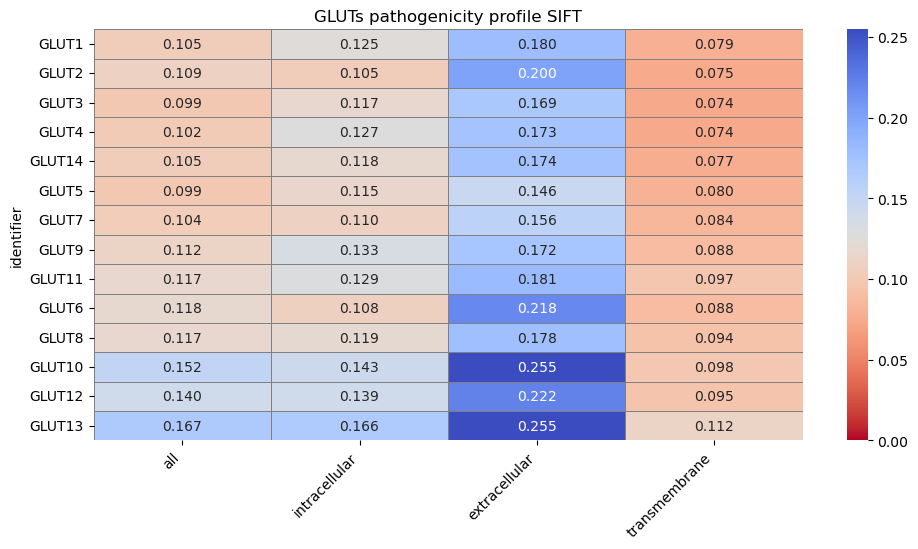

In [17]:
#create heatmaps
#sift
analysis.crate_heatmap(R_RES_DIR / r'pathogenicities/sift/united_averages.csv', 'SIFT', R_RES_DIR / 'SIFT_pathogenicity_heatmap.png', inverse_color = True)